Created on 21/07/2026

This script is used to extract and check profiles from multiple sources.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Data from GME (prices), ARSTool (PV and loads), and Swiss grid (FCR remuneration rates) 

In [2]:
if False:
    #------------------------------------------------------------------------------------------------
    # PROFILES
    #------------------------------------------------------------------------------------------------

    # Reading the Excel files
    C_ele_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\GME_20240101_20241231_MGP_PrezziZonali_CSUD.xlsx", decimal=',')
    # print(C_ele_original)
    Pl_Ppv_Pwt_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\Dati ENEA.xlsx")
    # print(Pl_Ppv_Pwt_original)


    # Extraction of useful profiles
    C_ele_full = C_ele_original['€/MWh'].tolist()               # zonal price (CSUD 2024) [€/MWh], from 01/01/24 to 31/12/24 (leap year, 366 days)
    C_ele = np.array(C_ele_full[:1416] + C_ele_full[1440:])     # removing 29th Feb data to have 365 days (8760 hours) and turning into ndarray
    # C_ele = np.append(C_ele, C_ele[0])                        # make the array go from 0 to 8760 (8761 values)

    C_ele_sell = C_ele / 2

    Pl_comm_to_arrange = Pl_Ppv_Pwt_original['Commerciale'].tolist()            # commercial load profile [p.u.], from 16/10/20 to 15/10/21
    Pl_comm = np.array(Pl_comm_to_arrange[1848:] + Pl_comm_to_arrange[:1848])   # rearranged data from 01/01/21 to 15/10/21 and then from 16/10/20 to 31/12/20

    Pl_ind_to_arrange = Pl_Ppv_Pwt_original['Industriale'].tolist()             # industrial load profile [p.u.], from 16/10/20 to 15/10/21
    Pl_ind = np.array(Pl_ind_to_arrange[1848:] + Pl_ind_to_arrange[:1848])

    Pl_resid_to_arrange = Pl_Ppv_Pwt_original['Residenziale'].tolist()          # residential load profile [p.u.], from 16/10/20 to 15/10/21
    Pl_resid = np.array(Pl_resid_to_arrange[1848:] + Pl_resid_to_arrange[:1848])

    Ppv_to_arrange = Pl_Ppv_Pwt_original['PV'].tolist()         # PV generation profile [??], from 16/10/20 to 15/10/21
    P_pv = np.array(Ppv_to_arrange[1848:] + Ppv_to_arrange[:1848])

    Pwt_to_arrange = Pl_Ppv_Pwt_original['Wind'].tolist()       # WT generation profile [??], from 16/10/20 to 15/10/21
    P_wt = np.array(Pwt_to_arrange[1848:] + Pwt_to_arrange[:1848])


    # Reading the PARQUET file containing the FCR remuneration rate data
    FCR_data_path = r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\market_price_measurement_FCR-cap_CH_2022.parquet"
    C_FCR_original = pd.read_parquet(FCR_data_path, engine="fastparquet")
    # print(C_FCR_original)

    # Exporting the dataframe into an Excel file to check the data
    # C_FCR_original.to_excel('market_price_measurement_FCR-cap_CH_2022.xlsx', sheet_name='Data Export', index=False)

    # Extracting specific columns (max, average, min data)
    C_FCR_fullmax = C_FCR_original['max'].tolist()
    C_FCR_fullavg = C_FCR_original['avg'].tolist()
    # C_FCR_fullmin = C_FCR_original['min'].tolist()

    # Selecting only one year (2024) and removing the 29th Feb data to have 365 days (8760 / 4 values)
    C_FCR_max4h = np.array(C_FCR_fullmax[4380:4734] + C_FCR_fullmax[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
    C_FCR_avg4h = np.array(C_FCR_fullavg[4380:4734] + C_FCR_fullavg[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
    # C_FCR_min = np.array(C_FCR_fullmin[4380:4734] + C_FCR_fullmin[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)

    # Repeating the data to have 1-hour intervals instead of 4-hours ones 
    C_FCR_max = np.zeros(8760)
    C_FCR_avg = np.zeros(8760)
    for t in range(len(C_FCR_max4h)):
        for i in range(4):
            C_FCR_max[4*t + i] = C_FCR_max4h[t]
            C_FCR_avg[4*t + i] = C_FCR_avg4h[t]


    # Checking the data -----------------------------------------------------------------------------------
    time = np.arange(0, 8760)

    # Plot settings
    plt.rc('figure', figsize=(20, 20))
    plt.rc('font', family='monospace', weight='bold', size=11)
    plt.rc('axes', labelsize=11, titlesize=14)
    plt.rc('legend', fontsize=11)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rcParams['axes.grid'] = True
    plt.rcParams['lines.linewidth'] = 2

    # """
    # Plots
    fig, axs = plt.subplots(8, 1, layout='constrained')
    axs[0].plot(time, C_ele, color='blue')
    axs[0].set_xlabel('x label')
    axs[0].set_ylabel('y label')
    axs[0].set_title("Electricity Price [€/MWh]")
    axs[0].legend()

    axs[1].plot(time, Pl_comm)
    axs[1].set_title("Commercial load [p.u.]")
    axs[2].plot(time, Pl_ind)
    axs[2].set_title("Industrial load [p.u.]")
    axs[3].plot(time, Pl_resid)
    axs[3].set_title("Residential load [p.u.]")
    axs[4].plot(time, P_pv)
    axs[4].set_title("PV generation [??]")
    axs[5].plot(time, P_wt)
    axs[5].set_title("WT generation [??]")
    axs[6].plot(time, C_FCR_max)
    axs[6].set_title("FCR remuneration rates (max) [€/MWh]")
    axs[7].plot(time, C_FCR_avg)
    axs[7].set_title("FCR remuneration rates (avg) [€/MWh]")
    # """


    # Profiles adjustments based on rated powers
    Ppv_rtd = 3
    Pl_comm_rtd = 1
    Pl_ind_rtd = 1
    Pl_resid_rtd = 1

    Pl_comm = Pl_comm * Pl_comm_rtd         # Commercial load profile [MW]
    Pl_ind = Pl_ind * Pl_ind_rtd            # Industrial load profile [MW]
    Pl_resid = Pl_resid * Pl_resid_rtd      # Residential load profile [MW]
    P_load = Pl_ind + Pl_comm              # load profile used in the optimization problem [MW]
    P_pv = (P_pv / 2) * Ppv_rtd             # PV generation profile [MW]
    # Pwt = Pwt * Pwt_rtd                   # WT generation profile [MW]

    # Scaling the FCR remuneration rates
    multiplier_FCR = 1
    C_FCR = C_FCR_avg * multiplier_FCR

    # """
    # Checking the data after adjustments
    fig, axs = plt.subplots(5, 1, layout='constrained')
    axs[0].plot(time, C_ele, color='blue')
    axs[0].set_xlabel('x label')
    axs[0].set_ylabel('y label')
    axs[0].set_title("Electricity Price [€/MWh]")
    axs[0].legend()

    axs[1].plot(time, Pl_comm)
    axs[1].set_title("Commercial load [MW]")
    axs[2].plot(time, Pl_ind)
    axs[2].set_title("Industrial load [MW]")
    axs[3].plot(time, Pl_resid)
    axs[3].set_title("Residential load [MW]")
    axs[4].plot(time, P_pv)
    axs[4].set_title("PV generation [MW]")
    # axs[5].plot(time, P_wt)
    # axs[5].set_title("WT generation")
    # """

#### Data from New Jersey dataset (PV and loads), and Swiss grid (FCR remuneration rates)

In [3]:
if False:
    # Reading the Excel/csv files
    Pl_resid_original = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Carichi\New Jersey Dataset on Hourly Load Profiles for 24 Facilities (8760 hours)\Residential.csv")
    Pl_ind_original = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Carichi\New Jersey Dataset on Hourly Load Profiles for 24 Facilities (8760 hours)\Industrial-General Manufacturer.csv")
    Pl_off_original = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Carichi\New Jersey Dataset on Hourly Load Profiles for 24 Facilities (8760 hours)\Reference-Office.csv")

    Ppv_df = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Generazione\New Jersey PV generation data 2026 (Actual, DA, HA4)\Actual_39.35_-75.25_2006_UPV_13MW_5_Min.csv")


    # Extraction of useful profiles
    Pl_resid_list = Pl_resid_original['Power [kW]'].tolist()    # residential load profile [kW], from 01/01 to 31/12 (year unspecified), 1-hour steps
    # print(Pl_resid_list)
    Pl_ind_list = Pl_ind_original['Power [kW]'].tolist()        # industrial (general manufacturer) load profile [kW], from 01/01 to 31/12 (year unspecified), 1 hour steps 
    Pl_off_list = Pl_off_original['Power [kW]'].tolist()        # office load profile [kW], from 01/01 to 31/12 (year unspecified), 1 hour steps

    Ppv_original = Ppv_df['Power(MW)'].tolist()                 # PV generation profile from a 13 MW plant [MW], from 01/01/06 to 31/12/06, 5-min steps
    Ppv_15min = np.zeros(8760 * 4)                              # PV generation profile 15-min steps
    Ppv_1h = np.zeros(8760)                                     # PV generation profile 1-hour steps
    for t in range(len(Ppv_15min)):
        Ppv_15min[t] = np.mean(Ppv_original[t*3: (t+1)*3])
    for t in range(len(Ppv_1h)):
        Ppv_1h[t] = np.mean(Ppv_original[t*12: (t+1)*12])


    # Normalize the data based on peak power (loads) or rated power (PV)
    peak_resid = np.max(Pl_resid_list)                            
    Pl_resid_pu = Pl_resid_list / peak_resid

    peak_ind = np.max(Pl_ind_list)
    Pl_ind_pu = Pl_ind_list / peak_ind

    peak_off = np.max(Pl_off_list)
    Pl_off_pu = Pl_off_list / peak_off

    Ppv_rtd_original = 13        # rated PV power of the original data PV plant
    Ppv_15min_pu = Ppv_15min / Ppv_rtd_original
    Ppv_1h_pu = Ppv_1h / Ppv_rtd_original
    # NOTE: il profilo in p.u. raggiunge al massimo 0.8378

    # print(Pl_resid_pu)
    # print(peak_resid)
    # print(Pl_ind_pu)
    # print(peak_ind)
    # print(Pl_off_pu)
    # print(peak_off)


    # Scale the data based on the sizes chosen for the case study
    Ppv_rtd = 3
    Pl_resid_rtd = 1
    Pl_ind_rtd = 1
    Pl_off_rtd = 1

    Pl_resid = Pl_resid_pu * Pl_resid_rtd    # yearly residential load profile [kW]
    Pl_ind = Pl_ind_pu * Pl_ind_rtd          # yearly industrial load profile [kW]
    Pl_off = Pl_off_pu * Pl_off_rtd          # yearly office load profile [kW]
    Ppv_15min = Ppv_15min_pu * Ppv_rtd       # yearly PV generation profile, 15-min steps [kW]
    Ppv_1h = Ppv_1h_pu * Ppv_rtd             # yearly PV generation profile, 1-hour steps [kW]

    day = 94    # 04/04: è il giorno che contiene il picco di produzione dell'impianto
    print(Ppv_15min_pu[day * 96 : (day + 1) * 96])
    # day = 91    # 01/04: è il giorno che contiene il picco di produzione dell'impianto
    # print(Ppv_15min_pu[day * 96 : (day + 1) * 96])
    # day = 90    # 31/03: è il giorno che contiene il picco di produzione dell'impianto
    # print(Ppv_15min_pu[day * 96 : (day + 1) * 96])


    # Reading the PARQUET file containing the FCR remuneration rate data
    FCR_data_path = r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\market_price_measurement_FCR-cap_CH_2022.parquet"
    C_FCR_original = pd.read_parquet(FCR_data_path, engine="fastparquet")
    # print(C_FCR_original)

    # Exporting the dataframe into an Excel file to check the data
    # C_FCR_original.to_excel('market_price_measurement_FCR-cap_CH_2022.xlsx', sheet_name='Data Export', index=False)

    # Extracting specific columns (max, average, min data)
    C_FCR_fullmax = C_FCR_original['max'].tolist()
    C_FCR_fullavg = C_FCR_original['avg'].tolist()
    # C_FCR_fullmin = C_FCR_original['min'].tolist()

    # Selecting only one year (2024) and removing the 29th Feb data to have 365 days (8760 / 4 values)
    C_FCR_max4h = np.array(C_FCR_fullmax[4380:4734] + C_FCR_fullmax[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
    C_FCR_avg4h = np.array(C_FCR_fullavg[4380:4734] + C_FCR_fullavg[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
    # C_FCR_min = np.array(C_FCR_fullmin[4380:4734] + C_FCR_fullmin[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)

    # Repeating the data to have 1-hour intervals instead of 4-hours ones 
    C_FCR_max = np.zeros(8760)
    C_FCR_avg = np.zeros(8760)
    for t in range(len(C_FCR_max4h)):
        for i in range(4):
            C_FCR_max[4*t + i] = C_FCR_max4h[t]
            C_FCR_avg[4*t + i] = C_FCR_avg4h[t]



    # Checking the data -----------------------------------------------------------------------------------
    time = np.arange(0, 8760)
    time_15min = np.arange(0, 8760 * 4)

    # Plot settings
    plt.rc('figure', figsize=(20, 20))
    plt.rc('font', family='monospace', weight='bold', size=11)
    plt.rc('axes', labelsize=11, titlesize=14)
    plt.rc('legend', fontsize=11)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rcParams['axes.grid'] = True
    plt.rcParams['lines.linewidth'] = 2

    # Plots --------
    # Original data
    fig, axs = plt.subplots(7, 1, layout='constrained')
    axs[0].plot(time, Pl_resid_pu)
    axs[0].set_title("Residential load [p.u.]")
    axs[1].plot(time, Pl_ind_pu)
    axs[1].set_title("Industrial load [p.u.]")
    axs[2].plot(time, Pl_off_pu)
    axs[2].set_title("Office load [p.u.]")
    axs[3].plot(time_15min, Ppv_15min_pu)
    axs[3].set_title("PV generation (Dt = 15 min) [p.u.]")
    axs[4].plot(time, Ppv_1h_pu)
    axs[4].set_title("PV generation (Dt = 1 h) [p.u.]")
    axs[5].plot(time, C_FCR_max)
    axs[5].set_title("FCR remuneration rates (max) [€/MWh]")
    axs[6].plot(time, C_FCR_avg)
    axs[6].set_title("FCR remuneration rates (avg) [€/MWh]")

    # Scaled data
    fig, axs = plt.subplots(5, 1, layout='constrained')
    axs[0].plot(time, Pl_resid)
    axs[0].set_title("Residential load [kW]")
    axs[1].plot(time, Pl_ind)
    axs[1].set_title("Industrial load [kW]")
    axs[2].plot(time, Pl_off)
    axs[2].set_title("Office load [kW]")
    axs[3].plot(time_15min, Ppv_15min)
    axs[3].set_title("PV generation (Dt = 15 min) [kW]")
    axs[4].plot(time, Ppv_1h)
    axs[4].set_title("PV generation (Dt = 1 h) [kW]")

#### Data from Swiss grid / Switzerland (electricity prices, PV, loads, and FCR remuneration rates)
In particular: Electricity prices and loads from ENTSO-E transparency platform, FCR prices from Swissgrid website, and PV data from local HEIG-VD system.  

263088
315647
2190


Text(0.5, 1.0, 'FCR remuneration rates [€/MWh]')

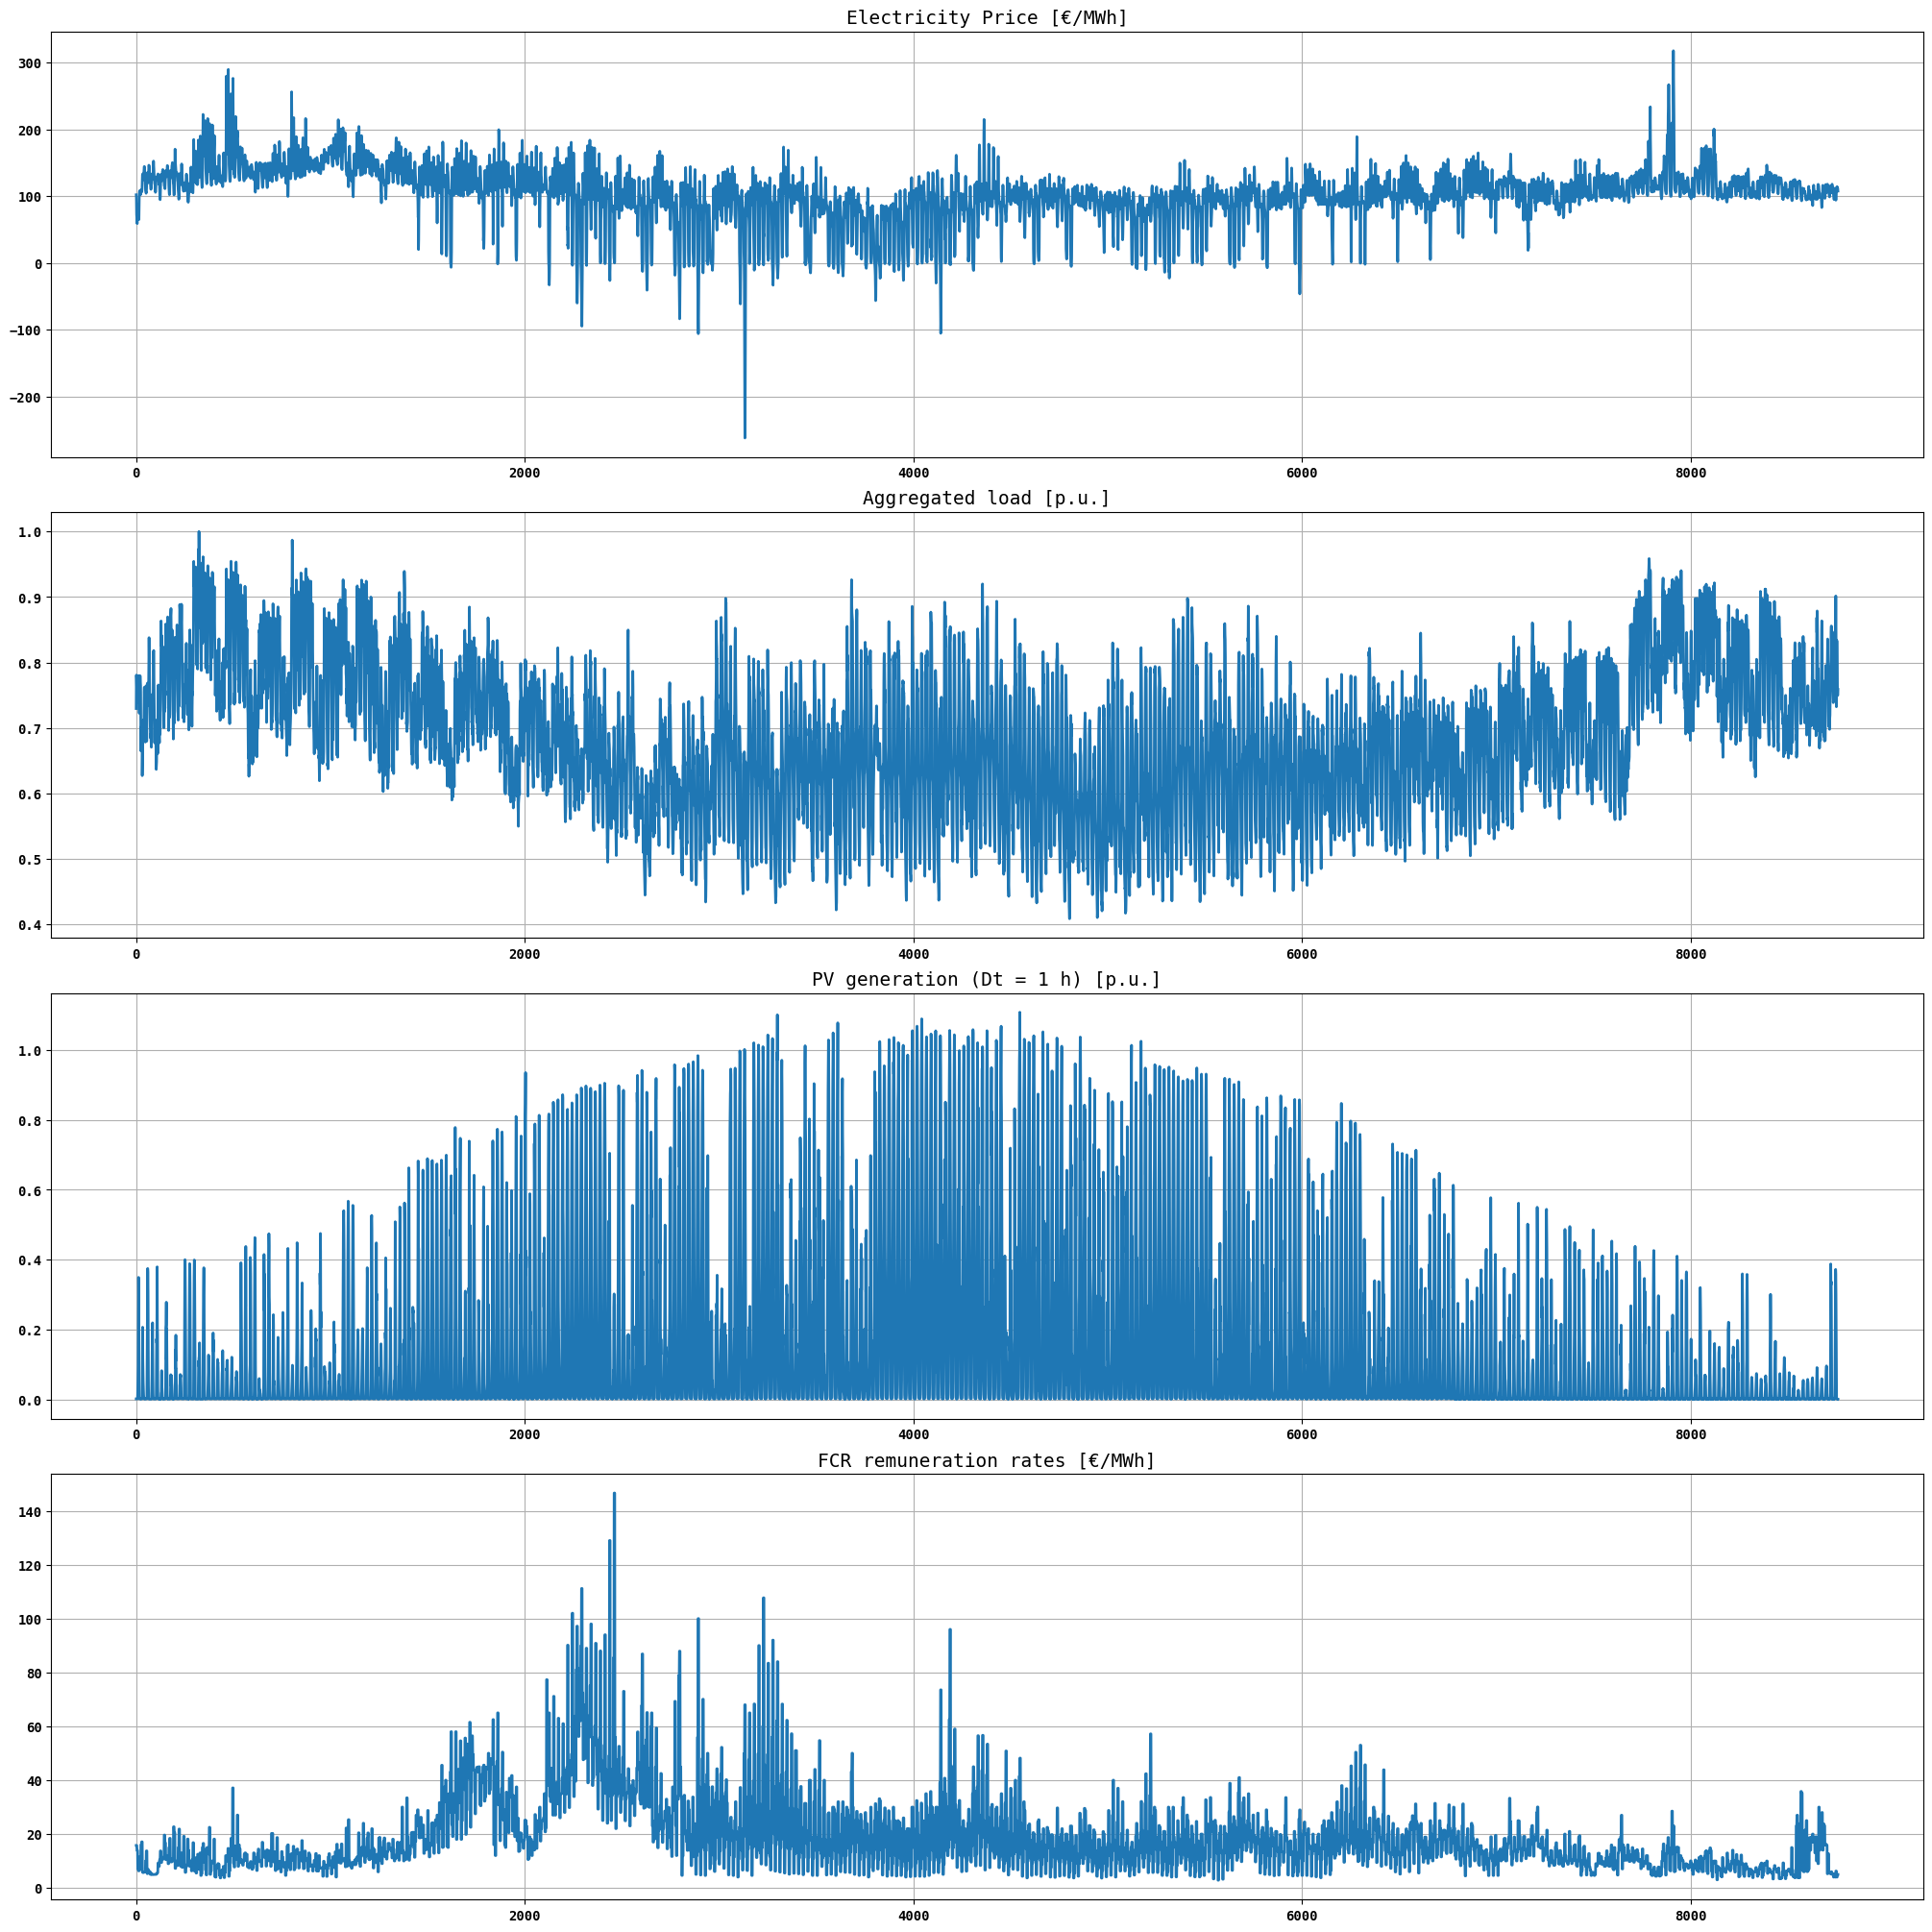

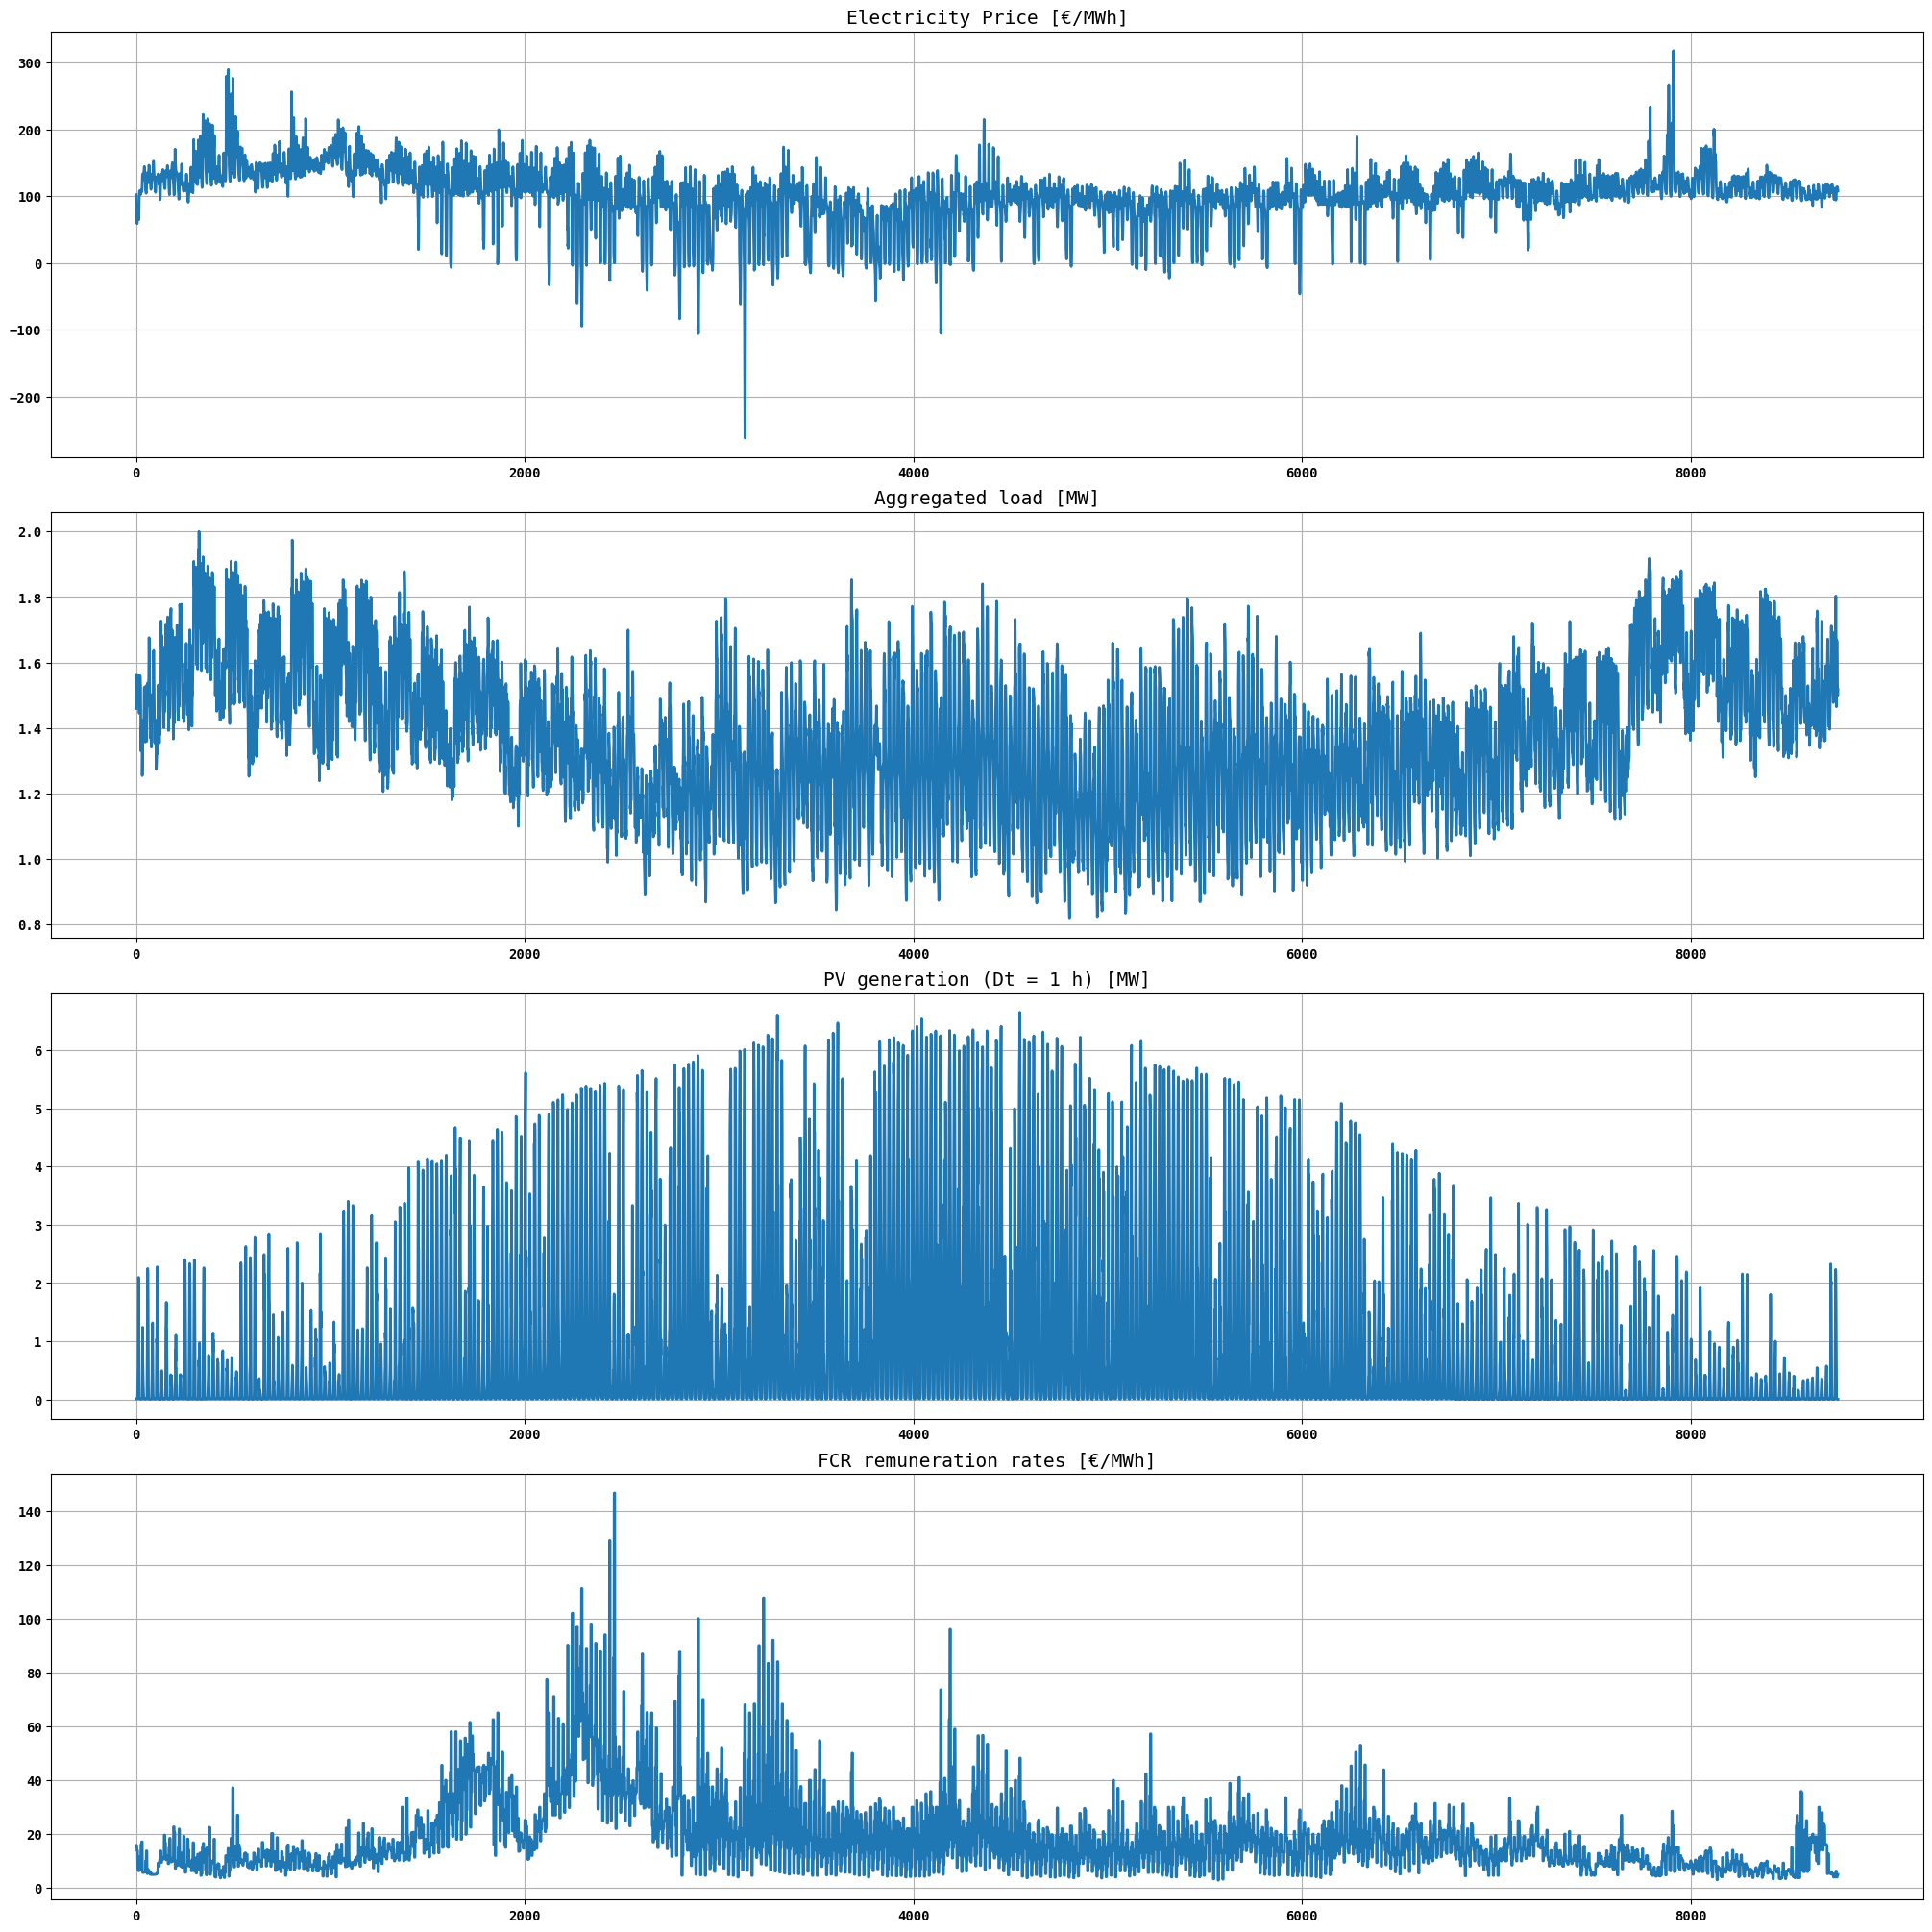

In [15]:
# Reading the Excel/csv files ----------------------------------------
# Electricity price -----
C_ele_original = pd.read_csv(
    r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Prezzi\Energia elettrica\Svizzera\Day-ahead\GUI_ENERGY_PRICES_202501010000-202601010000.csv",
    sep=',',
    escapechar='\\',
    quoting=3  # csv.QUOTE_NONE: ignores the surrounding quotes that put everything together in a single row string
)
# Clean up remaining quote marks from column names and string values
C_ele_original.columns = C_ele_original.columns.str.replace('"', '')
C_ele_original = C_ele_original.apply(lambda col: col.str.replace('"', '') if col.dtype == "object" else col)
# print(C_ele_original)

# Load -----
Pl_aggr_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Carichi\Svizzera\Carico totale rete svizzera\Carico totale rete svizzera 2025.xlsx", 
                                header=[0, 1])
# print(Pl_aggr_original)

# PV -----
# Ppv_df = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Generazione\New Jersey PV generation data 2026 (Actual, DA, HA4)\Actual_39.35_-75.25_2006_UPV_13MW_5_Min.csv")
Irr_temp_df = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Generazione\Svizzera\ogd-smn_mah_t_historical_2020-2029.csv",
                    sep=';',
                    low_memory=False)
# print(Irr_temp_df)


# Data processing for extraction of useful profiles ----------------------------------------
# Electricity price -----
C_ele_list = pd.to_numeric(C_ele_original['Day-ahead Price (EUR/MWh)'], errors='coerce').tolist()    # electricity price profile [€/MWh], from 01/01/25 to 31/12/25, 1-hour steps
C_ele = np.array(C_ele_list)

# Load -----
Pl_aggr_original_list = Pl_aggr_original[('\nTotal energy consumption Swiss controlblock', 'kWh')].tolist()    # aggregated load profile [kWh], from 01/01/2025 to 31/12/2025, 15-min steps
# The two columns of data are identified by the following tuple headers:
# ('Total energy consumed by end users in the Swiss controlblock', 'kWh'), ('\nTotal energy consumption Swiss controlblock', 'kWh')
Pl_aggr_original_15min = np.array(Pl_aggr_original_list) / 1e3    # aggregated load profile [MW], from 01/01/2025 to 31/12/2025, 15-min steps
Pl_aggr_original_1h = np.zeros(8760)
for t in range(len(Pl_aggr_original_1h)):
    Pl_aggr_original_1h[t] = np.mean(Pl_aggr_original_15min[t*4 : (t+1)*4])

# PV -----
# Slicing to have only the data related to 2025
first_index_PV2025 = (Irr_temp_df['reference_timestamp'] == '01.01.2025 00:00').idxmax()    # idxmax finds the first row that satisfies a defined condition
last_index_PV2025 = (Irr_temp_df['reference_timestamp'] == '31.12.2025 23:50').idxmax()
Irr_temp_df_2025 = Irr_temp_df.iloc[first_index_PV2025 : last_index_PV2025 + 1, :]
print(first_index_PV2025)
print(last_index_PV2025)
# print(Irr_temp_df_2025)

# Selecting the columns with irradiance and temperature data
Irr_temp_times_list = Irr_temp_df_2025['reference_timestamp'].tolist()
Irr_original = Irr_temp_df_2025['gre000z0'].tolist()    # irradiance list [W/m^2], from 01/01/2025 to to 31/12/2025, 10-min steps
Temp_original = Irr_temp_df_2025['tre200s0'].tolist()    # irradiance list [W/m^2], from 01/01/2025 to to 31/12/2025, 10-min steps
# print(Irr_temp_times_list)
# print(Irr_original)
# print(Temp_original)

# Converting irradiance and temperature into hourly profiles
Irr_1h = np.zeros(8760)    # irradiance profile [W/m^2], from 01/01/2025 to to 31/12/2025, 1-hour steps
Temp_1h = np.zeros(8760)    # temperature profile [°C], from 01/01/2025 to to 31/12/2025, 1-hour steps
for t in range(len(Irr_1h)):
    Irr_1h[t] = np.mean(Irr_original[t*6 : (t+1)*6])
    Temp_1h[t] = np.mean(Temp_original[t*6 : (t+1)*6])

# Converting irrandiance and temperature profiles into PV power profiles (1 MW plant)
def irr_to_pvpower(irr, temp_amb):
    NOCT = 48
    Ppv_std = 1e3    # rated PV power of the plant [kW]
    irr_std = 1000
    temp_std = 25
    beta_P = 0.003
    eta_inv = 0.98

    temp_cell = temp_amb + (NOCT - 20) * (irr / 800)
    Ppv_dc = Ppv_std * (irr / irr_std) * (1 + beta_P * (temp_cell - temp_std))
    Ppv_ac_kw = eta_inv * Ppv_dc / 1e3

    return Ppv_ac_kw

Ppv_1h_pu = irr_to_pvpower(Irr_1h, Temp_1h)    # PV generation profile for a 1 MW plant [MW], from 01/01/2025 to to 31/12/2025, 1-hour steps
# print(Ppv_1h_original)


# Normalize the data where needed, based on peak power (loads) or rated power (PV) ----------------------------------------
peak_load = np.max(Pl_aggr_original_1h)                            
Pl_aggr_pu = Pl_aggr_original_1h / peak_load
# print(Pl_aggr_pu)
# print(peak_load)

# Scale the data based on the sizes chosen for the case study
Ppv_rtd = 6
Pl_aggr_rtd = 2

Pl_aggr = Pl_aggr_pu * Pl_aggr_rtd       # yearly aggregated load profile [MW]
# Ppv_15min = Ppv_15min_pu * Ppv_rtd       # yearly PV generation profile, 15-min steps [MW]
Ppv_1h = Ppv_1h_pu * Ppv_rtd             # yearly PV generation profile, 1-hour steps [MW]


# Reading the original file containing the FCR auctions data -----------------------------------------------------------
auction_data_original = pd.read_csv(
    r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Prezzi\Energia elettrica\Svizzera\FCR\2025-PRL-SRL-TRL-Ergebnis - Translated.csv",
    sep=';',
    low_memory=False)
# print(list(C_FCR_original.columns))
# List of all column headers: ['Tender / Auction', 'Description', 'Bid Volume / Bid Quantity', 'Unit',
# 'Awarded Volume / Allocated Quantity', 'Unit.1', 'Capacity Price', 'Unit.2', 'Costs', 'Unit.3', 'Price', 'Unit.4',
# 'Country', 'Bid Price', 'Unit.5', 'Divisibility']

# Removing data not associated with Switzerland (CH)
auction_data_CH = auction_data_original[auction_data_original['Country'] == 'CH'].reset_index(drop=True)

# Removing the last rows, pertaining to secondary and tertiary frequency regulation (SRL, TRL)
first_index_nonFCR = (auction_data_CH['Tender / Auction'] == 'SRL_25_09_30').idxmax()    # idxmax finds the first row that satisfies a defined condition
auction_data_CH_FCR = auction_data_CH.iloc[:first_index_nonFCR, :]

# Extracting the final auction price ("Marginal Clearing Price")
# The logic is as follows: two lists are defined, one for the bidding times (column 'Description') and one for the clearing price (column 'Price').
# While inspecting every row, whenever a new bidding time is encountered, the corresponding bidding price is appended to the clearing prices list
rows, cols = auction_data_CH_FCR.shape
C_FCR_4h = []      # list of the FCR prices
C_FCR_4h.append(auction_data_CH_FCR.at[0, 'Price'])
bid_times_list = [auction_data_CH_FCR.at[0, 'Description']]    # list of the descripions of the bidding times (hours)
bid_days_list = [auction_data_CH_FCR.at[0, 'Tender / Auction']]    # list of the descripions of the bidding times (days)

for r in range(rows):
    if bid_times_list[-1] != auction_data_CH_FCR.at[r, 'Description']:
        C_FCR_4h.append(auction_data_CH_FCR.at[r, 'Price'])
        bid_times_list.append(auction_data_CH_FCR.at[r, 'Description'])
        bid_days_list.append(auction_data_CH_FCR.at[r, 'Tender / Auction'])

print(len(C_FCR_4h))
# print(bid_times_list[1984])
# print(bid_days_list[1984])
# print(C_FCR[1984])
# NOTE: the FCR remuneration prices are expressed in €/MWh, meaning that these prices are paid for every hour in which the allocated capacity is provided.
# In other words, the price for the 4-hour product is 4 times bigger than the ones in C_FCR_4h


# Checking the data -----------------------------------------------------------------------------------
# Repeating the data to have 1-hour intervals instead of 4-hours ones 
C_FCR_1h = np.zeros(8760)
for t in range(len(C_FCR_4h)):
    for i in range(4):
        C_FCR_1h[4*t + i] = C_FCR_4h[t]

time = np.arange(0, 8760)

# Plot settings
plt.rc('figure', figsize=(20, 20))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2

# Plots --------
# Original data
fig, axs = plt.subplots(4, 1, layout='constrained')
axs[0].plot(time, C_ele)
axs[0].set_title("Electricity Price [€/MWh]")
axs[1].plot(time, Pl_aggr_pu)
axs[1].set_title("Aggregated load [p.u.]")
axs[2].plot(time, Ppv_1h_pu)
axs[2].set_title("PV generation (Dt = 1 h) [p.u.]")
axs[3].plot(time, C_FCR_1h)
axs[3].set_title("FCR remuneration rates [€/MWh]")

# Scaled data
fig, axs = plt.subplots(4, 1, layout='constrained')
axs[0].plot(time, C_ele)
axs[0].set_title("Electricity Price [€/MWh]")
axs[1].plot(time, Pl_aggr)
axs[1].set_title("Aggregated load [MW]")
axs[2].plot(time, Ppv_1h)
axs[2].set_title("PV generation (Dt = 1 h) [MW]")
axs[3].plot(time, C_FCR_1h)
axs[3].set_title("FCR remuneration rates [€/MWh]")